In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests
import keras
from PIL import Image, ImageOps
import requests
import io
from sklearn.model_selection import train_test_split
from keras.models import Model
from keras.layers import Dense, Input, Conv2D, MaxPooling2D, Flatten
from keras.optimizers import SGD
from keras.losses import MeanSquaredError

2026-03-13 18:38:46.365208: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
airbnb = pd.read_csv('airbnb_clean.csv')

In [10]:
airbnb.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_profile_id', 'host_profile_url', 'host_name',
       'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minim

In [4]:
df = airbnb.head(50)
display(df)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20251204025441,2025-12-06,previous scrape,Superfast Wi-Fi. Clean & quiet home by the park,"Bright, serene room in a renovated apartment h...",Close to Prospect Park and Historic Ditmas Park,https://a0.muscache.com/pictures/hosting/Hosti...,2787,...,5.00,4.75,4.88,NaN,f,7,1,6,0,0.07
1,2595,https://www.airbnb.com/rooms/2595,20251204025441,2025-12-05,city scrape,Skylit Studio Oasis | Midtown Manhattan Sanctuary,Prime Midtown | Spacious 500 Sq Ft | Pyramid S...,Centrally located in the heart of Manhattan ju...,https://a0.muscache.com/pictures/hosting/Hosti...,2845,...,4.80,4.81,4.40,NaN,f,3,3,0,0,0.24
2,6848,https://www.airbnb.com/rooms/6848,20251204025441,2025-12-04,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.80,4.69,4.59,NaN,f,1,1,0,0,0.98
3,6872,https://www.airbnb.com/rooms/6872,20251204025441,2025-12-05,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,This sweet Harlem sanctuary is a 10-20 minute ...,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.00,5.00,5.00,NaN,f,2,0,2,0,0.05
4,6990,https://www.airbnb.com/rooms/6990,20251204025441,2025-12-05,city scrape,UES Beautiful Blue Room,Beautiful peaceful healthy home,"Location: Five minutes to Central Park, Museum...",https://a0.muscache.com/pictures/45fb4ec7-6856...,16800,...,4.94,4.85,4.83,NaN,f,1,0,1,0,1.27
5,7064,https://www.airbnb.com/rooms/7064,20251204025441,2025-12-06,previous scrape,"Amazing location! Wburg. Large, bright & tranquil","Large, private loft-like room in a spacious 2-...","- One stop from the East Village, Lower East S...",https://a0.muscache.com/pictures/13708959/7e74...,17297,...,5.00,5.00,5.00,NaN,f,2,0,2,0,0.07
6,7097,https://www.airbnb.com/rooms/7097,20251204025441,2025-12-06,previous scrape,"Perfect for Your Parents, With Garden & Patio",Parents/grandparents coming to town or are you...,"Residential, village-like atmosphere. Lots of ...",https://a0.muscache.com/pictures/aaac19fc-4b4d...,17571,...,4.93,4.95,4.82,OSE-STRREG-0000008,t,2,0,2,0,2.19
7,7801,https://www.airbnb.com/rooms/7801,20251204025441,2025-12-05,city scrape,Sunny Prime Williamsburg Loft with Sauna,A huge loft in a repurposed factory building i...,We've lived here for over 15 years and love Wi...,https://a0.muscache.com/pictures/miso/Hosting-...,21207,...,4.78,5.00,4.89,NaN,f,1,1,0,0,0.06
8,60457,https://www.airbnb.com/rooms/60457,20251204025441,2025-12-06,previous scrape,Spacious Greenwich Village Apt,Large one bedroom in the perfect neighborhood ...,Greenwich village is a quiet classic part of N...,https://a0.muscache.com/pictures/98823897-8827...,99212,...,5.00,5.00,4.71,NaN,f,1,1,0,0,0.05
9,60611,https://www.airbnb.com/rooms/60611,20251204025441,2025-12-05,city scrape,SpaHa Studio Monthly Rental,This is the real New York City experience: Spa...,Our neighborhood is quite safe and everyone ta...,https://a0.muscache.com/pictures/ad70dcaf-4ec7...,292204,...,4.98,4.60,4.80,NaN,f,4,4,0,0,1.11


## Borough Classification from Airbnb Listing Images

In this project we aim to predict the NYC borough of an Airbnb listing purely from its thumbnail image. The hypothesis is that listings across different boroughs (Manhattan, Brooklyn, Queens, the Bronx, and Staten Island) may have visually distinct characteristics in how they are photographed and presented. For example, Manhattan listings might skew toward sleek, modern interiors or high-rise views, while Brooklyn listings may reflect more ndustrial or brownstone aesthetics and the rest of the boroughs may have pictures that do not target tourists altogether. 

By training a CNN to classify borough from image alone, we aim to explore whether these visual differences are strong enough to be learnable and gain insight into how Airbnb hosts across different parts of the city choose to represent their units.

we are on item 1
we are on item 2
Skipping row 2: HTTPSConnectionPool(host='a0.muscache.com', port=443): Read timed out. (read timeout=3.5)
Skipping row 3: HTTPSConnectionPool(host='a0.muscache.com', port=443): Read timed out. (read timeout=3.5)
Skipping row 4: HTTPSConnectionPool(host='a0.muscache.com', port=443): Read timed out. (read timeout=3.5)
we are on item 3
Skipping row 6: HTTPSConnectionPool(host='a0.muscache.com', port=443): Read timed out. (read timeout=3.5)
we are on item 4
we are on item 5
we are on item 6
we are on item 7
we are on item 8
we are on item 9
we are on item 10
we are on item 11
Skipping row 15: HTTPSConnectionPool(host='a0.muscache.com', port=443): Read timed out. (read timeout=3.5)
we are on item 12
we are on item 13
Skipping row 18: HTTPSConnectionPool(host='a0.muscache.com', port=443): Read timed out. (read timeout=3.5)
we are on item 14
we are on item 15
we are on item 16
we are on item 17
we are on item 18
we are on item 19
we are on item 20
we are on i

we are on item 230
we are on item 231
we are on item 232
we are on item 233
Skipping row 269: HTTPSConnectionPool(host='a0.muscache.com', port=443): Read timed out. (read timeout=3.5)
we are on item 234
we are on item 235
we are on item 236
we are on item 237
Skipping row 274: HTTPSConnectionPool(host='a0.muscache.com', port=443): Read timed out. (read timeout=3.5)
we are on item 238
we are on item 239
we are on item 240
we are on item 241
we are on item 242
we are on item 243
we are on item 244
we are on item 245
we are on item 246
we are on item 247
Skipping row 285: HTTPSConnectionPool(host='a0.muscache.com', port=443): Read timed out. (read timeout=3.5)
we are on item 248
we are on item 249
we are on item 250
we are on item 251
Skipping row 290: HTTPSConnectionPool(host='a0.muscache.com', port=443): Read timed out. (read timeout=3.5)
Skipping row 291: HTTPSConnectionPool(host='a0.muscache.com', port=443): Read timed out. (read timeout=3.5)
we are on item 252
we are on item 253
Skip

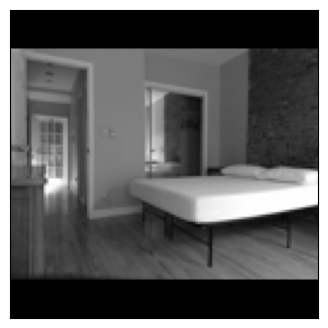

In [13]:
img_rows, img_cols = 128, 128
count = 1

def convert_image_to_grayscale_with_padding_from_url(url, target_width, target_height):
    global count
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, stream=True, timeout=3.5)
    response.raise_for_status()
    print(f'we are on item {count}')
    count += 1
    img = Image.open(io.BytesIO(response.content))
    img = img.convert('L')
    padded_img = ImageOps.pad(img, (target_width, target_height), color=0)
    return np.array(padded_img)

df = airbnb.head(350)

images = []
valid_indices = []

for i, url in enumerate(df['picture_url']):
    try:
        img_array = convert_image_to_grayscale_with_padding_from_url(url, img_cols, img_rows)
        images.append(img_array)
        valid_indices.append(i)
    except Exception as e:
        print(f"Skipping row {i}: {e}")

X = np.array(images, dtype=np.float32)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
neighbourhood_series = df['neighbourhood_group_cleansed'].iloc[valid_indices]
y_raw = neighbourhood_series.values

valid_mask = pd.notna(y_raw)
X = X[valid_mask]
y_raw = y_raw[valid_mask]

y = le.fit_transform(y_raw).astype(np.int32)
num_classes = len(le.classes_)

print(f"Valid samples: {len(y)}")
print(f"Classes ({num_classes}): {le.classes_}")

unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f"  {cls}: {cnt}")

X = X / 255.0
X = X[..., np.newaxis]

min_count = np.min(np.bincount(y))
stratify_arg = y if min_count >= 2 else None
if stratify_arg is None:
    print("Warning: a class has <2 samples, skipping stratify")

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify_arg
)

def plot_img(x, im_shape):
    plt.imshow(x.reshape(im_shape), cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.gcf().set_size_inches(4, 4)

plot_img(x_train[0], im_shape=(img_rows, img_cols))

# Build CNN
inpx = Input(shape=(img_rows, img_cols, 1))
x = Conv2D(16, (3,3), activation='relu', padding='same')(inpx)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dense(64,  activation='relu')(x)
out = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=inpx, outputs=out)
model.compile(optimizer=SGD(learning_rate=0.01),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=32, epochs=10, validation_split=0.1)

score = model.evaluate(x_test, y_test, verbose=0)
print('Test Loss=', score[0])
print('Test Accuracy=', score[1])

pred_test = model.predict(x_test[:5])
pred_classes = le.inverse_transform(np.argmax(pred_test, axis=1))
actual_classes = le.inverse_transform(y_test[:5])
print("Predicted neighbourhood_group:", pred_classes)
print("Actual neighbourhood_group:   ", actual_classes)

## Neighbourhood-Level Classification & Emerging Market Prediction

Building on the borough-level classifier, a subsequent step involves training a more refined CNN to predict outcomes at the neighbourhood level. Distinguising similiar neighbourhoods like  Williamsburg from Crown Heights or the Upper East Side from Hell's Kitchen. At this level of resolution, the visual cues become increasingly subtle with the model having to look at variations in interior design trends, building architecture, natural illumination, and staging styles.

By integrating image derived features with listing data such as price trends, review volume growth, and host listing counts over time, it may be possible to identify "up and coming" neighbourhoods areas where the quality of listings is improving at a pace exceeding price growth or where new hosts are investing in professional photography. These signals, observable in the images prior to their full reflection in pricing data, could serve as  indicators of neighbourhoods gaining momentum on the platform and likely in real life as well. 